In [1]:
import jax
from jax import flatten_util, vmap, grad 
import jax.numpy as jnp
import jax.random as jr

from scipy.signal import savgol_filter
from scipy.interpolate import CubicSpline

import matplotlib.pyplot as plt
from functools import partial
import optax
from helper_fns_general import sample_gaussian_mixture, normalize_samples, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization, setup_overdamped_SDE, solve_SDE, sample_forward_process, setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch
from plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, get_best_params
jax.config.update("jax_enable_x64", True)

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


### Generate samples from a Gaussian mixture

In [2]:
# Set random seed
key = jr.PRNGKey(0)

# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 10000

# Define mixture weights (must sum to 1)
weights = jnp.array([.3, .7])

# Define means
# Define means
means = jnp.array([
    [0.5, 0.0],   # mean of first Gaussian
    [-0.5, 0.5],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.01, 0.0],    # covariance of first Gaussian
        [0.0, 0.01]],
    [[0.01, 0.0],   # covariance of second Gaussian
        [0.0, 0.01]],
])
# Generate samples
samples_0 = sample_gaussian_mixture(key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)



### Plot samples and marginal distributions

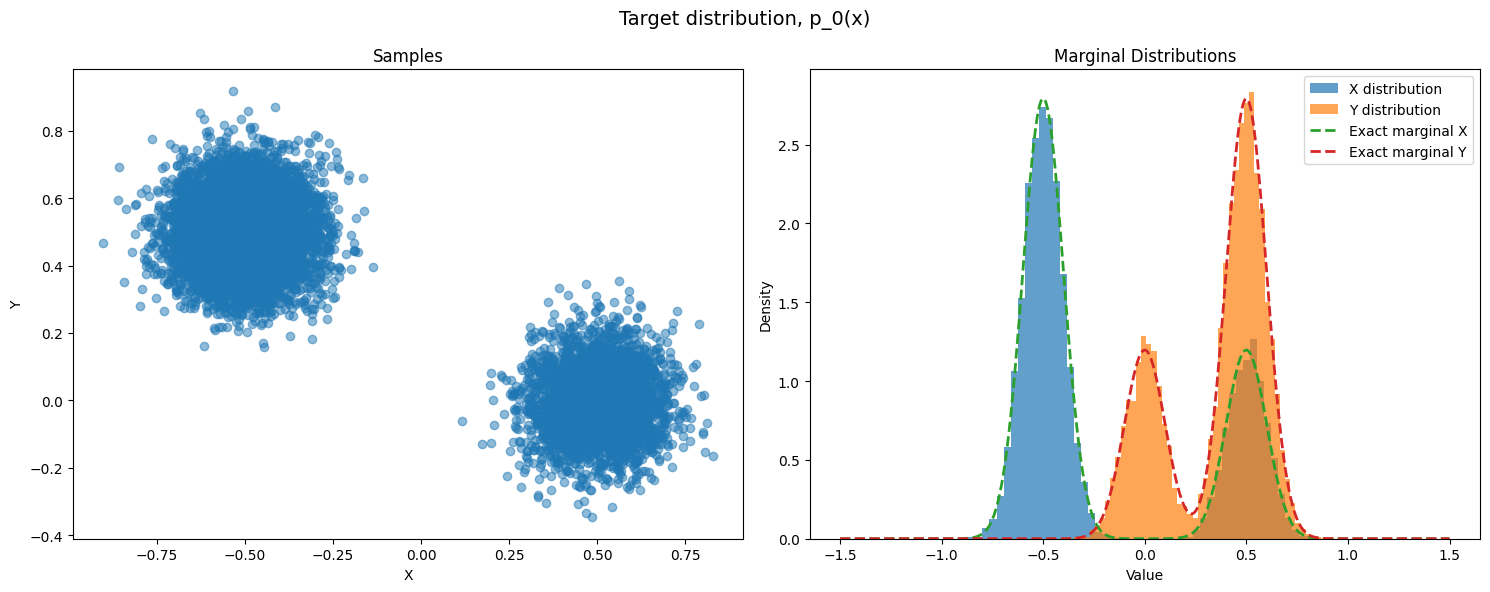

In [3]:
# ... existing code ...

# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples_0[:, 0], samples_0[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_0[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_0[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')

# Add exact marginal Gaussians
x = jnp.linspace(-1.5, 1.5, 1000)
for dim in range(2):
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax2.plot(x, marginal, '--', linewidth=2, label=f'Exact marginal {["X", "Y"][dim]}')

ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

In [4]:
key, subkey = jr.split(key)
t_forward = 2.0
diffusion_rate = 1.0
samples_t = sample_forward_process(t_forward, n_samples, D=1, samples0=samples_0, key=subkey, diffusion_rate=diffusion_rate)

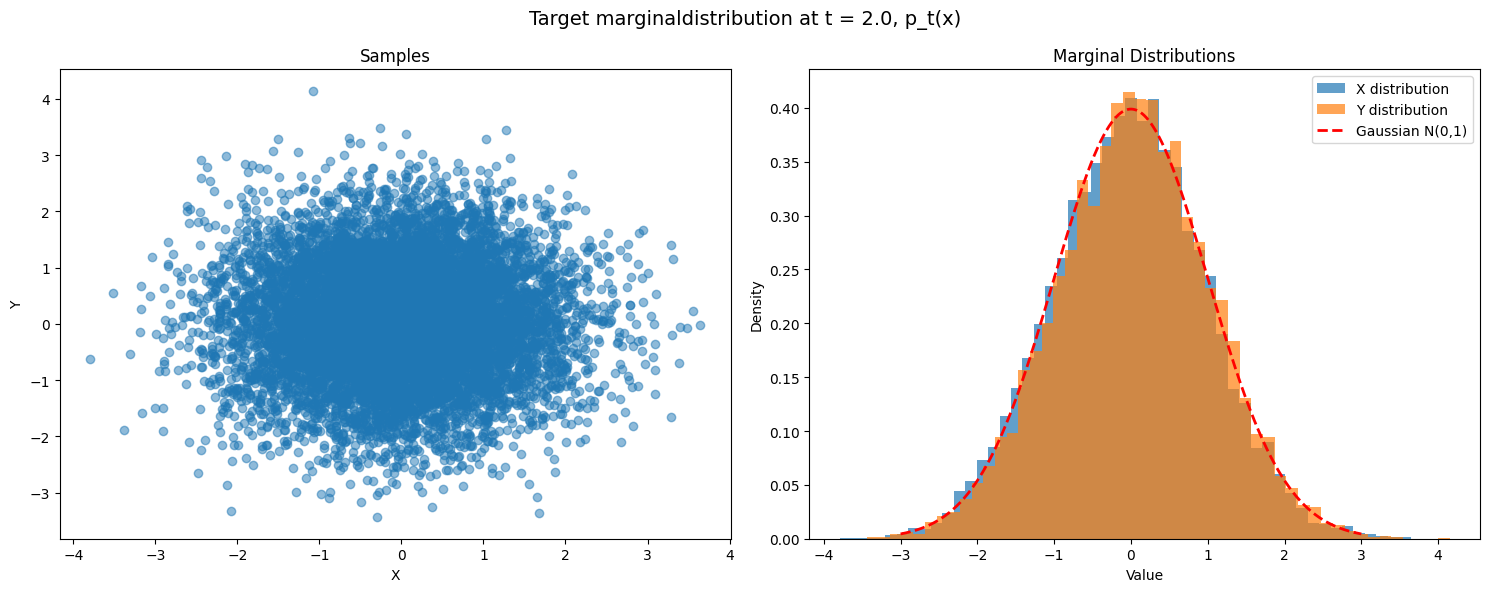

In [5]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Target marginaldistribution at t = {t_forward}, p_t(x)', fontsize=14)


# First subplot: Scatter plot of samples
ax1.scatter(samples_t[:, 0], samples_t[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_t[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_t[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')

# Add Gaussian N(0,1) for comparison
x = jnp.linspace(-3, 3, 1000)  # Adjust range as needed
gaussian_pdf = (1 / jnp.sqrt(2 * jnp.pi)) * jnp.exp(-0.5 * x**2)
ax2.plot(x, gaussian_pdf, 'r--', linewidth=2, label='Gaussian N(0,1)')

ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

### Define energy function of duffing oscillator network

In [6]:
def energy_self_oscillator(x, k_lin, k_duff):
    return 1 / 2 * k_lin * x**2 + 1 / 4 * k_duff * x**4

def energy_self_network(x, k_lin, k_duff):
    return jnp.sum(vmap(energy_self_oscillator)(x, k_lin, k_duff))


def energy_coupling_pair(x, y, c_lin, c_optomech):
    return c_lin * x * (x - y) + c_lin * y * (y - x) + c_optomech * (x**2) * y

def energy_coupling_network(x, c_lin, c_optomech, connectivity):
    # get contribution to total energy from each pair of oscillators
    
    def _coupling_energy_pair(x, c_lin, c_optomech, pair):
        # get energy of one pair of oscillators
        i, j = pair
        return energy_coupling_pair(x[i], x[j], c_lin, c_optomech)

    # get energy of all pairs of oscillators
    return jnp.sum(
        vmap(_coupling_energy_pair, in_axes=(None, 0, 0, 0))(
            x, c_lin, c_optomech, connectivity
        )
    )


def _energy_duffing_network(x, k_lin, k_duff, c_lin, c_optomech, connectivity, k_b=1., T=1.):
    # returns energy of network of oscillators given input parameters
    return (
        energy_self_network(x, k_lin, k_duff) +
        energy_coupling_network(x, c_lin, c_optomech, connectivity)
    ) / (k_b * T)

### Define initial parameters

In [7]:
N_osc = 2

k_lin_0 = jnp.array([-1., -1.])
k_duff_0 = jnp.array([1., 0.])
c_lin_0 = jnp.array([0.,])
c_optomech_0 = jnp.array([0.,])
connectivity = jnp.array([[0, 1]])

args_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0)

flattened_args_initial, unflatten = flatten_util.ravel_pytree(args_initial)

### Bringe energy into correct form

In [8]:
def energy_duffing_network(x, flattened_args, connectivity):
    k_lin, k_duffing, c_lin, c_optomech = unflatten(flattened_args)
    return _energy_duffing_network(x, k_lin, k_duffing, c_lin, c_optomech, connectivity)
energy_fn = lambda x, flattened_args: energy_duffing_network(x, flattened_args, connectivity)

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


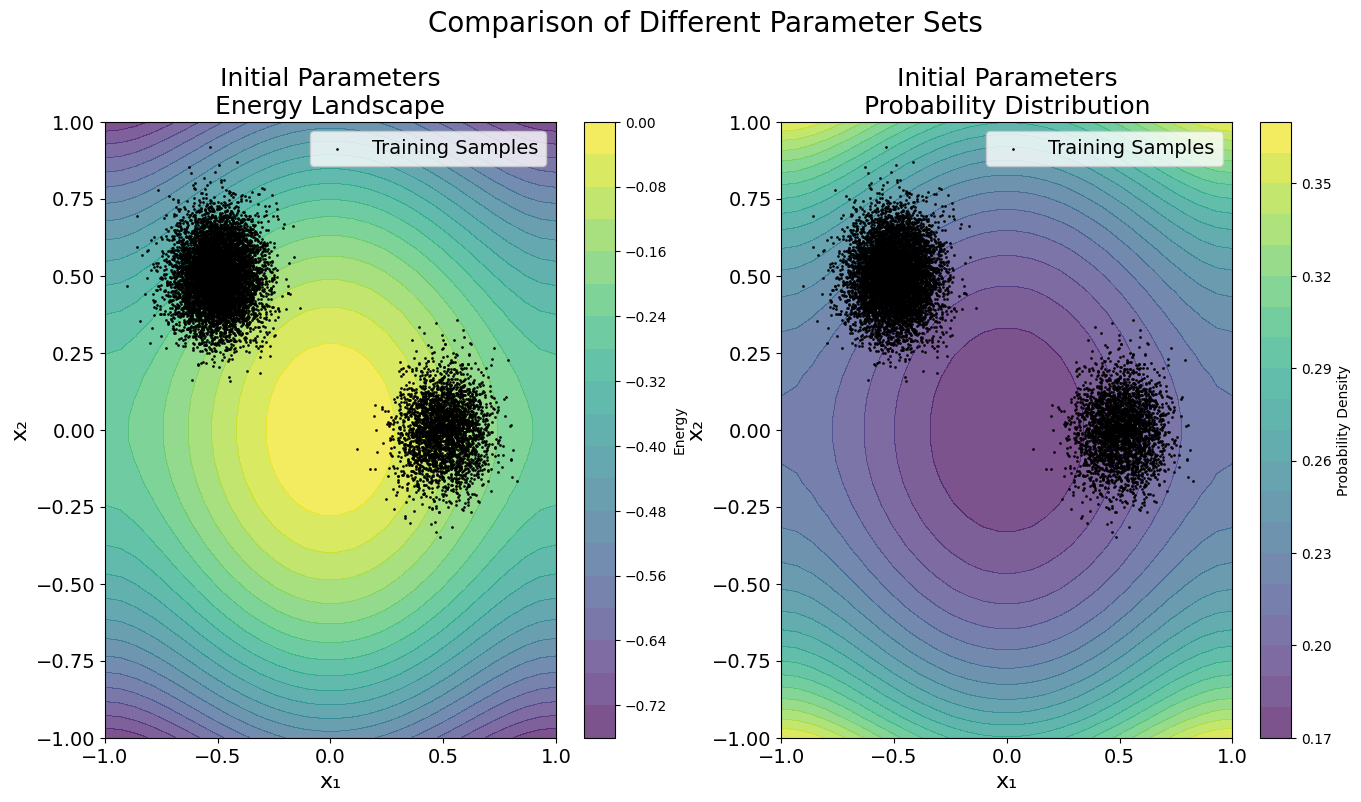

In [9]:
# Example usage:
param_list = [flattened_args_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples_0,
    x1_range=(-1, 1),   
    x2_range=(-1, 1),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Comparison of Different Parameter Sets" 
)

In [10]:
# Choose training method
training_method = "SM"  # Options: "SM" (Score Matching), "CD1" (Contrastive Divergence), "MLE" (Maximum Likelihood)

# Setup loss and gradient functions based on selected method
if training_method == "SM":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = None
    maximize = False
elif training_method == "CD1":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = lambda flattened_args, batch: -CD1_gradient(energy_fn, batch, flattened_args, dt=0.001, D=1, key=key, num_noise_samples=1000)
    maximize = False
elif training_method == "MLE":
    loss_fn_per_batch = setup_MLE_loss_per_batch(energy_fn)
    gradient_fn_per_batch = setup_MLE_gradient_per_batch(energy_fn)
    maximize = True
else:
    raise ValueError(f"Unknown training method: {training_method}. Choose from 'SM', 'CD1', or 'MLE'.")

In [11]:
# Define filename for saving/loading parameters
n_time_steps = 50
# forward_time_pts = jnp.linspace(0., t_forward, n_time_steps)
forward_time_pts = jnp.exp(jnp.linspace(jnp.log(1e-6), jnp.log(t_forward), n_time_steps))

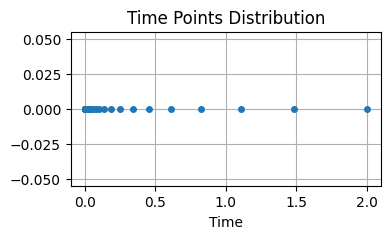

In [12]:
plt.figure(figsize=(4, 2))
plt.plot(forward_time_pts, jnp.zeros_like(forward_time_pts), 'o', markersize=4)
plt.xlabel('Time')
plt.ylabel('')
plt.title('Time Points Distribution')
plt.grid(True)
plt.show()

Optimizing for t = 0.000
Epoch 0
params:
[-0.9 -0.9  1.1  0.1  0.1  0.1]
Loss: 1.3821
---
Epoch 100
params:
[ 5.66929735  7.26242812 10.55932885  9.32996317 -1.49865837 -1.01875206]
Loss: -15.7909
---
Epoch 200
params:
[ 9.80716012 13.05950813 19.41140096 17.38223194 -3.21709887 -1.91310674]
Loss: -24.6482
---
Epoch 300
params:
[10.69038108 15.38802054 27.69756853 24.058514   -4.09986915 -2.45223818]
Loss: -28.4305
---
Epoch 400
params:
[ 9.66875314 15.16277943 35.72057232 30.0678329  -4.38922459 -2.66020488]
Loss: -32.6000
---
Epoch 500
params:
[ 7.19411614 13.52549285 43.52268435 35.71878307 -4.36739076 -2.53270072]
Loss: -37.3914
---
Epoch 600
params:
[ 4.51621019 11.46483329 51.20985633 41.24056939 -4.25759954 -2.60913884]
Loss: -39.1444
---
Epoch 700
params:
[ 1.70548992  9.16202082 58.72138067 46.60878287 -4.15198912 -2.65278309]
Loss: -41.7863
---
Epoch 800
params:
[-1.11677016  6.87163677 65.94959761 51.74437435 -3.99233809 -2.26138877]
Loss: -46.9756
---
Epoch 900
params:
[-3.

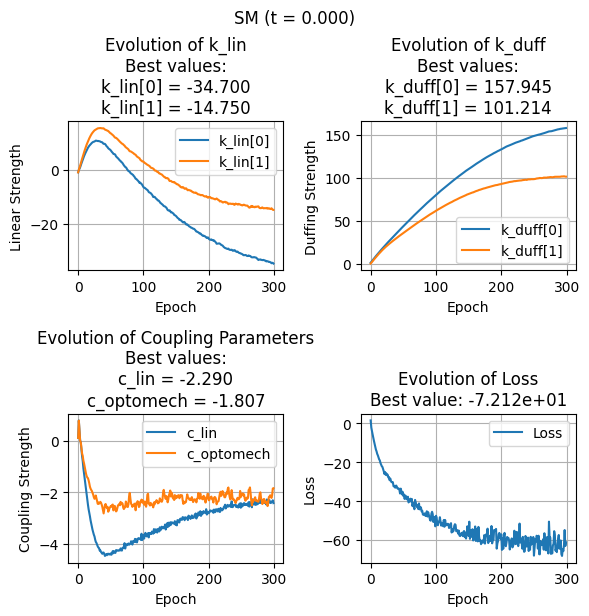

Optimizing for t = 0.000
Epoch 0
params:
[-34.80043257 -14.84999624 157.84516078 101.11402453  -2.39035437
  -1.90745988]
Loss: -59.6173
---
Epoch 100
params:
[-34.75949607 -15.06732888 160.33616256 101.22082166  -2.36672013
  -2.1508636 ]
Loss: -59.2230
---
Epoch 200
params:
[-35.82314384 -14.56710211 162.4905394  101.75035489  -2.36852765
  -2.40751973]
Loss: -58.3846
---
Epoch 300
params:
[-36.1544298  -15.03078903 163.7180024  101.06442841  -2.25472895
  -2.04312674]
Loss: -58.2788
---
Epoch 400
params:
[-36.45878568 -15.00164862 165.7195851  101.33938791  -2.2941192
  -2.12535592]
Loss: -58.3787
---
Epoch 500
params:
[-37.21137854 -15.18750497 166.02498012 100.7279858   -2.09607164
  -1.82343688]
Loss: -62.9293
---
Epoch 600
params:
[-37.36624625 -15.15549492 166.471868   101.15105459  -2.12144013
  -1.8893885 ]
Loss: -62.5714
---
Epoch 700
params:
[-37.15176642 -15.45095009 166.99096999 101.22430718  -2.11945338
  -2.01048769]
Loss: -65.9796
---
Epoch 800
params:
[-37.24224863 -1

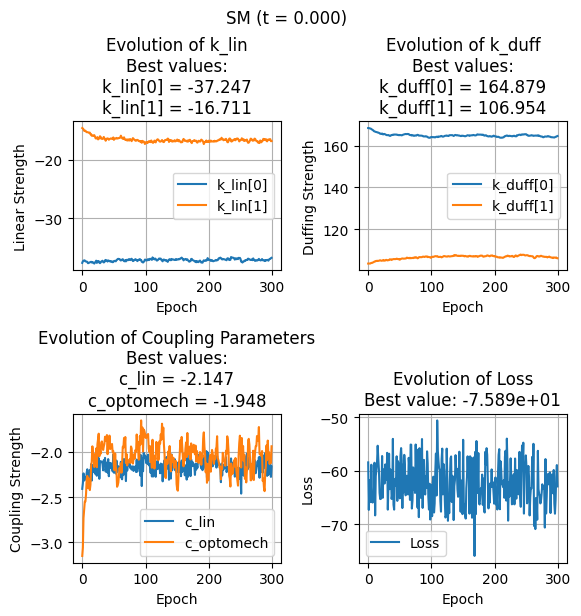

Optimizing for t = 0.000
Epoch 0
params:
[-37.14679475 -16.61101988 164.7792058  107.05401381  -2.0468016
  -1.84834838]
Loss: -57.3863
---
Epoch 100
params:
[-37.03465461 -17.24598168 165.15205674 108.87007941  -2.0860374
  -1.73641177]
Loss: -61.7005
---
Epoch 200
params:
[-37.41356201 -17.38955965 165.53866746 109.97484456  -2.18419848
  -1.65241792]
Loss: -54.0909
---
Epoch 300
params:
[-37.75767127 -17.89756529 165.89438349 110.36404116  -2.08928141
  -1.4799738 ]
Loss: -58.5418
---
Epoch 400
params:
[-37.86901034 -18.38611759 165.79292976 110.64261061  -2.08442638
  -1.38116912]
Loss: -56.3323
---
Epoch 500
params:
[-37.84577737 -18.35842323 166.02757051 110.91879805  -2.10428804
  -1.87963369]
Loss: -65.4579
---
Epoch 600
params:
[-37.92045423 -18.34844548 166.19739183 111.46018726  -2.15628135
  -1.71630935]
Loss: -64.2892
---
Epoch 700
params:
[-37.83452369 -18.82324805 165.807453   111.26301296  -2.11703882
  -1.46519339]
Loss: -63.7655
---
Epoch 800
params:
[-37.89587153 -18

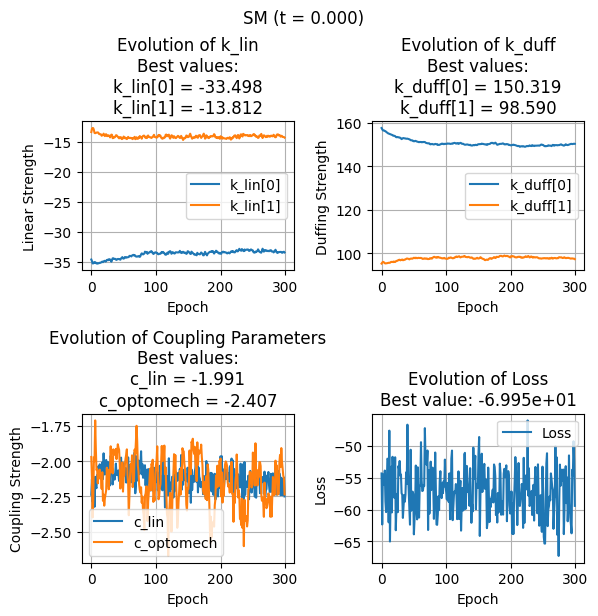

Optimizing for t = 0.001
Epoch 0
params:
[-33.59764955 -13.91196873 150.2192728   98.4898917   -2.09090347
  -2.50747913]
Loss: -46.8495
---
Epoch 100
params:
[-33.89228764 -14.94554284 149.07306693  95.63192655  -1.99209902
  -1.37589151]
Loss: -50.2647
---
Epoch 200
params:
[-33.76321862 -14.71432629 148.51277236  94.98242883  -1.86963866
  -1.25478056]
Loss: -55.1202
---
Epoch 300
params:
[-33.81785936 -14.79283978 148.17363578  93.22950565  -2.01727065
  -1.51765955]
Loss: -54.4641
---
Epoch 400
params:
[-33.69243808 -14.19466751 148.49467685  93.03564061  -1.96022967
  -1.33022368]
Loss: -59.5906
---
Epoch 500
params:
[-33.49282744 -14.52953597 148.2100545   91.99266328  -2.06479363
  -1.21319885]
Loss: -55.4124
---
Epoch 600
params:
[-33.47787805 -13.8997669  148.17242064  91.89598599  -1.9157191
  -1.37625489]
Loss: -56.3998
---
Epoch 700
params:
[-33.64618904 -13.8154997  148.11566617  91.54740581  -2.16673011
  -1.60311415]
Loss: -52.0324
---
Epoch 800
params:
[-33.80547581 -1

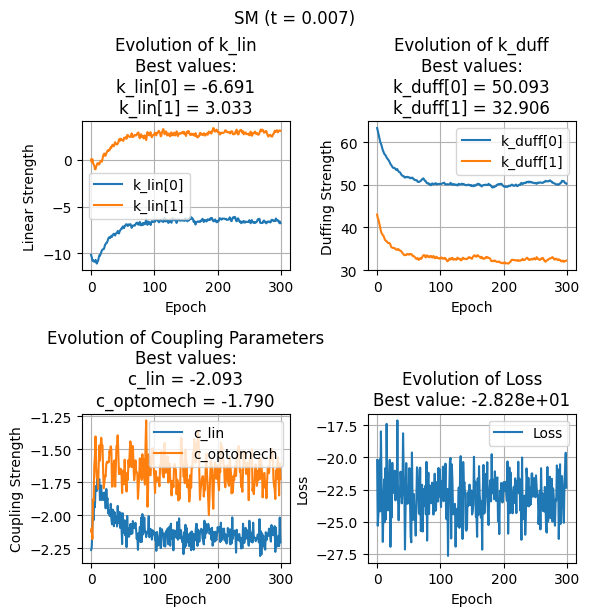

Optimizing for t = 0.010
Epoch 0
params:
[-6.7906644   2.93295926 49.99276804 32.80647663 -2.19311753 -1.89002968]
Loss: -20.0452
---
Epoch 100
params:
[-7.34095293  1.64721239 45.1594242  28.03127011 -1.67032175 -1.15435315]
Loss: -19.8435
---
Epoch 200
params:
[-6.17694551  2.07872615 42.71697508 26.42267238 -1.92963384 -1.17483738]
Loss: -17.5108
---
Epoch 300
params:
[-5.25449437  2.75147411 41.67466883 25.71875448 -1.96081925 -0.9897182 ]
Loss: -18.9587
---
Epoch 400
params:
[-4.80337864  2.95945261 40.39336048 25.24677351 -1.93708542 -1.02510777]
Loss: -20.0125
---
Epoch 500
params:
[-4.72722023  3.52505575 39.82808927 23.91840894 -1.9791724  -0.91729304]
Loss: -17.9040
---
Epoch 600
params:
[-4.5684227   3.56921157 40.36880711 24.24509504 -2.08646471 -0.97303325]
Loss: -16.8789
---
Epoch 700
params:
[-4.36392023  3.33249811 39.66259478 23.74417025 -1.97095655 -0.85392016]
Loss: -18.0729
---
Epoch 800
params:
[-4.3501363   3.84273201 39.97012941 24.13317789 -2.10483155 -1.1196237

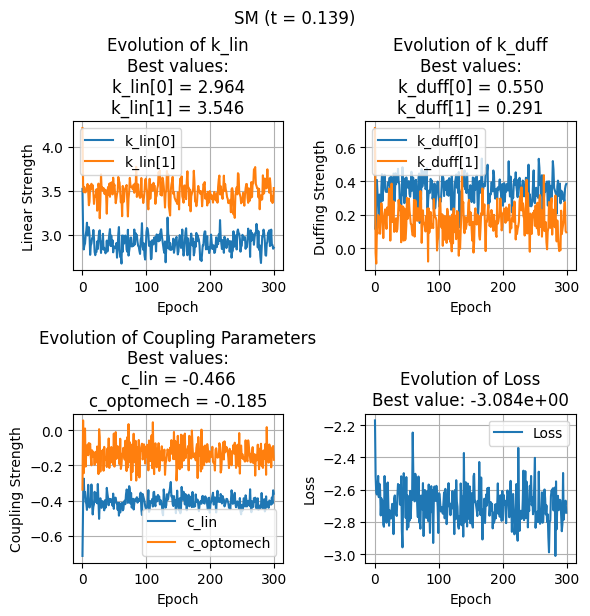

Optimizing for t = 0.187
Epoch 0
params:
[ 2.8644615   3.44590293  0.44954553  0.19121299 -0.56557435 -0.2846469 ]
Loss: -2.3178
---
Epoch 100
params:
[ 2.46539485  2.78390934  0.22956762  0.21168045 -0.2828315  -0.15321428]
Loss: -2.3858
---
Epoch 200
params:
[ 2.54947893  2.88201558  0.12848196  0.0380718  -0.29738833 -0.06762669]
Loss: -2.2974
---
Epoch 300
params:
[ 2.49911895  2.68588256  0.14053252  0.09165894 -0.288672   -0.14850169]
Loss: -2.2369
---
Epoch 400
params:
[ 2.60205649  2.83749584  0.07149159  0.1950121  -0.26876118 -0.13483782]
Loss: -2.3606
---
Epoch 500
params:
[ 2.41899747  2.73081769  0.19244248  0.0429218  -0.25030954 -0.2353926 ]
Loss: -2.2667
---
Epoch 600
params:
[ 2.48409182  3.0243564   0.16649219  0.19646959 -0.29234446 -0.15321493]
Loss: -2.3241
---
Epoch 700
params:
[ 2.38896593  2.78952952  0.25068784  0.22235754 -0.29735609 -0.12662436]
Loss: -2.2871
---
Epoch 800
params:
[ 2.34965121  2.66330644  0.11990388  0.05314151 -0.24520565 -0.06018009]
Loss:

In [13]:
load_param_histories = False
filename = f"out/parameter_histories/{training_method}/params_history_means_{means.flatten()}_covs_{covs.flatten()}_weights_{weights}_t_forward_{t_forward}_n_timestes_{n_time_steps}.npy"
if load_param_histories:
    # Load existing parameters
    params_history_all_t = jnp.load(filename)
else:
    # Setup optimization parameters
    mask = jnp.ones(flattened_args_initial.shape[0])
    # mask = mask.at[0].set(1.)
    # mask = mask.at[1].set(1.)
    # mask = mask.at[2].set(1.)
    learning_rate = 0.1
    n_epochs = 3000
    batch_size = 5*128

    # Plotting parameters
    plot_steps = True  # Flag to control whether to plot during optimization
    plot_slice = 10     # Plot every nth step


    # Initialize storage for parameters at each time step
    params_history_all_t = []
    current_params = flattened_args_initial

    # Loop over time points
    for t_idx, t_forward in enumerate(forward_time_pts):
        print(f"Optimizing for t = {t_forward:.3f}")
        
        # Generate samples at current time
        key, subkey = jr.split(key)
        samples_t = sample_forward_process(
            t_forward, n_samples, D=1, samples0=samples_0, key=subkey, diffusion_rate=diffusion_rate
        )
        
        # Perform optimization starting from previous best parameters
        key, subkey = jr.split(key)
        
        params_history, loss_history = run_optimization(
            loss_fn_per_batch=loss_fn_per_batch,
            params_initial=current_params,
            samples=samples_t,
            mask=mask,
            gradient_fn_per_batch=gradient_fn_per_batch,
            key=subkey,
            batch_size=batch_size,
            learning_rate=learning_rate,
            n_epochs=n_epochs,
            maximize=maximize
        )
        
        _, best_params, _ = get_best_params(params_history, loss_history, maximize=maximize)
        k_lin_best, k_duff_best, c_lin_best, c_optomech_best = unflatten(best_params)
        current_params, _ = flatten_util.ravel_pytree(best_params)
        params_history_all_t.append(current_params)
        
        if plot_steps:
            if t_idx % plot_slice == 0:
                # Plot optimization progress
                plot_parameter_evolution(
                    params_history=params_history,
                    loss_history=loss_history,
                    unflatten=unflatten,
                    N_osc=N_osc,
                    slicing=10,
                    title=f"{training_method} (t = {t_forward:.3f})",
                    maximize=maximize
                )
                # Plot current energy landscape
                # plot_energy_and_distributions(
                #     energy_fn=energy_fn,
                #     param_list=[current_params],
                #     samples=samples_t,
                #     x1_range=(-1, 1),
                #     x2_range=(-1, 1),
                #     n_points=30,
                #     titles=[f"t = {t_forward:.3f}"],
                #     fontsize=16,
                #     sample_stride=1,
                #     suptitle=f"Energy Landscape at t = {t_forward:.3f}"
                # )
            
    # Convert params_history_all_t to array for easier analysis
    params_history_all_t = jnp.array(params_history_all_t)
    jnp.save(filename, params_history_all_t)


### Smoothen and interpolate parameter evolution

In [14]:
def smooth_parameters(params, window_lengths = [31, 31, 31, 31, 31, 31], poly_orders = [3, 3, 3, 3, 3, 3]):
    """
    Smooths multiple parameter trajectories using Savitzky-Golay filter
    
    Args:
        params: Array of shape (n_timesteps, n_params) containing parameter trajectories
        window_lengths: List/array of window lengths for each parameter dimension
        poly_orders: List/array of polynomial orders for each parameter dimension
    
    Returns:
        Array of shape (n_timesteps, n_params) containing smoothed parameter trajectories
    """
    n_params = params.shape[1]
    smoothed = []
    
    for i in range(n_params):
        # Ensure window length is odd and valid
        window_length = min(window_lengths[i], len(params) - (1 - len(params) % 2))
        if window_length % 2 == 0:
            window_length -= 1
            
        # Smooth using Savitzky-Golay filter
        smoothed.append(savgol_filter(params[:, i], window_length, poly_orders[i]))
    
    return jnp.column_stack(smoothed)


def interpolate_parameters(params, time_points):
    """
    Interpolates parameter trajectories using jnp.interp in a vectorized fashion.

    Args:
        params: Array of shape (n_timesteps, n_params) containing parameter trajectories.
        time_points: 1D array of shape (n_timesteps,) corresponding to the time points.

    Returns:
        A function that takes time points `t` (scalar or 1D array) and returns
        the interpolated parameters. For scalar `t`, the result is shape (n_params,);
        for vector `t`, the result is shape (len(t), n_params).
    """
    
    def _interpolator(t):
        # Transpose params to shape (n_params, n_timesteps) so that each row is a trajectory.
        # Use vmap to apply jnp.interp over each parameter trajectory.
        interpolated = jax.vmap(lambda param: jnp.interp(t, time_points, param))(params.T)
        # If t is an array, jnp.interp returns an array for each parameter, resulting in a
        # (n_params, len(t)) array. Transpose it so that each row corresponds to a time point.
        if jnp.ndim(t) > 0:
            return interpolated.T
        return interpolated

    return _interpolator


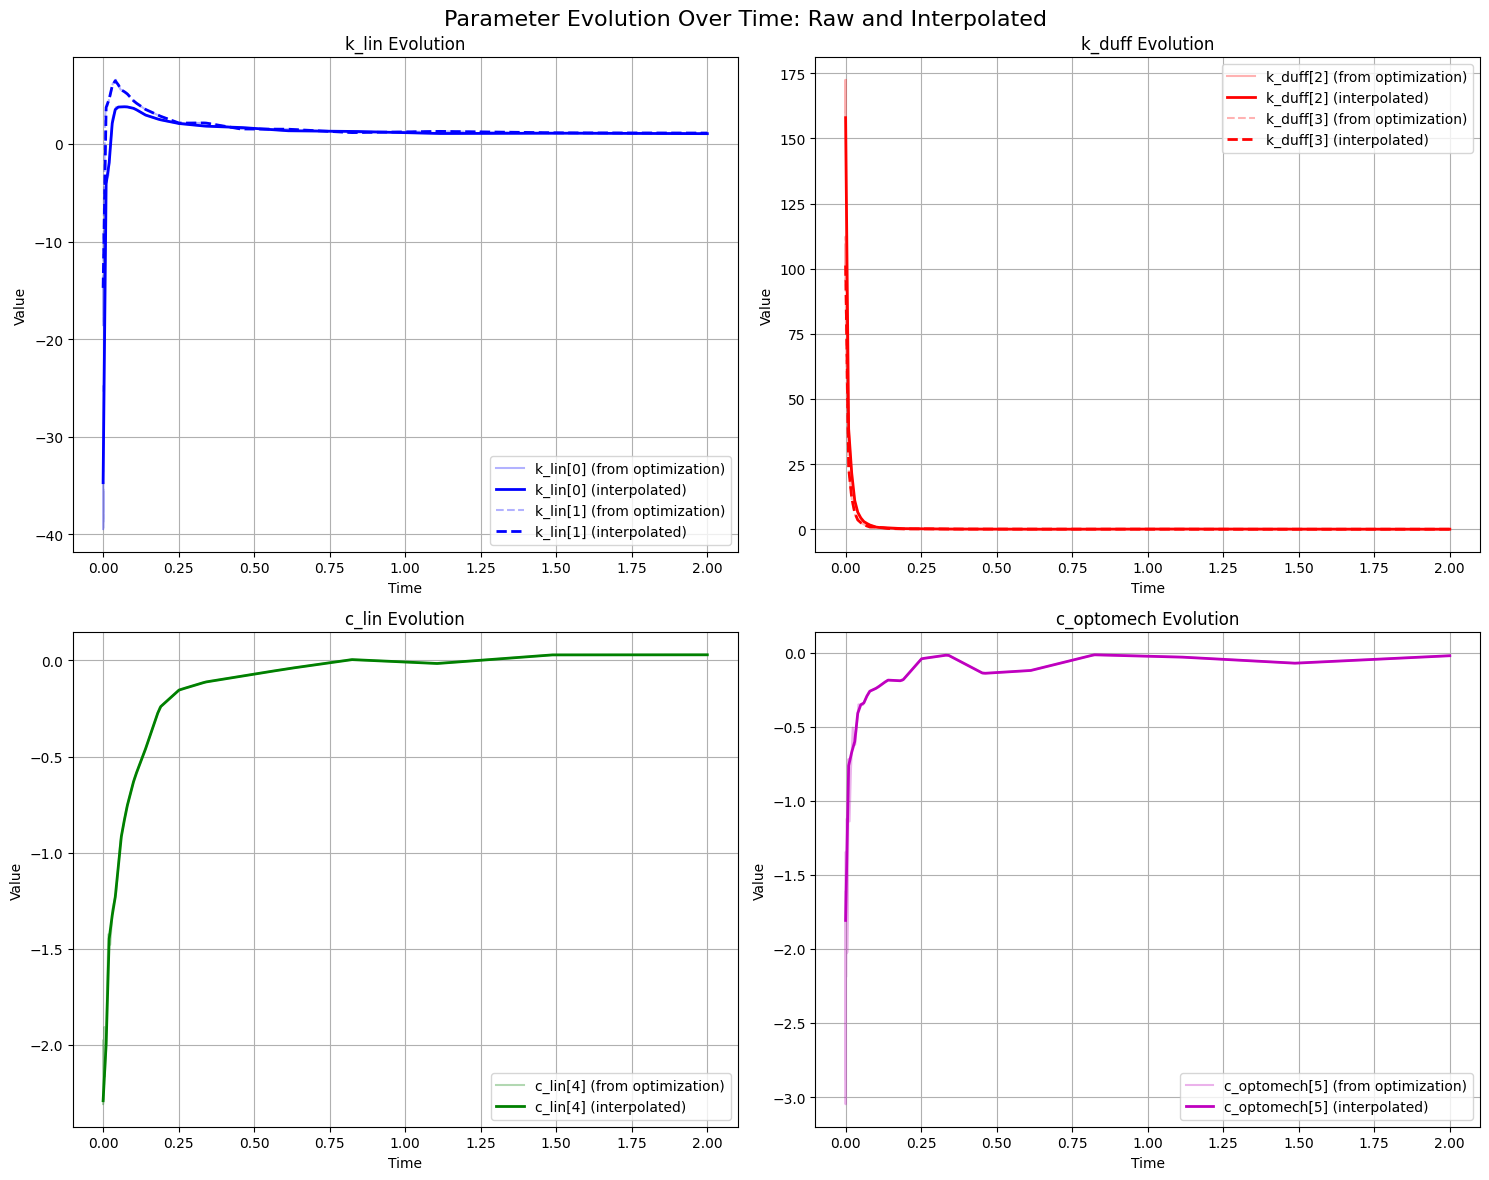

In [15]:
use_smoothed_params = False
if use_smoothed_params:
    # First smooth the parameters
    smoothed_params = smooth_parameters(params_history_all_t)
    # Get interpolator function
    params_interpolator = interpolate_parameters(smoothed_params, forward_time_pts)
else:
    # Get interpolator function
    params_interpolator = interpolate_parameters(params_history_all_t, forward_time_pts)

# Then interpolate the smoothed parameters
time_eval = jnp.linspace(forward_time_pts[0],forward_time_pts[-1],200)
# interpolated_params = interpolate_parameters(smoothed_params, forward_time_pts, time_dense)
interpolated_params = params_interpolator(time_eval)

# Create figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Parameter Evolution Over Time: Raw and Interpolated', fontsize=16)

# Plot settings
param_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech']
axes = [ax1, ax2, ax3, ax4]
colors = ['b', 'r', 'g', 'm']
param_indices = [(0,1), (2,3), (4,), (5,)]

# Plot for each parameter type
for ax, param_name, color, indices in zip(axes, param_names, colors, param_indices):
    for idx, style in zip(indices, ['-', '--']):
        # Plot raw data
        ax.plot(forward_time_pts, params_history_all_t[:, idx], color + style, alpha=0.3, 
                label=f'{param_name}[{idx}] (from optimization)')
        
        # Plot interpolated data
        ax.plot(time_eval, interpolated_params[:, idx], color + style, linewidth=2,
                label=f'{param_name}[{idx}] (interpolated)')
    
    ax.set_title(f'{param_name} Evolution')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

### Run reverse SDE:

In [16]:
forward_params = jnp.zeros_like(flattened_args_initial)
forward_params = forward_params.at[0].set(1.)
forward_params = forward_params.at[1].set(1.)
params_interpolator_reverse_plus_linear = lambda t: 2*params_interpolator(t_forward - t) - diffusion_rate*forward_params

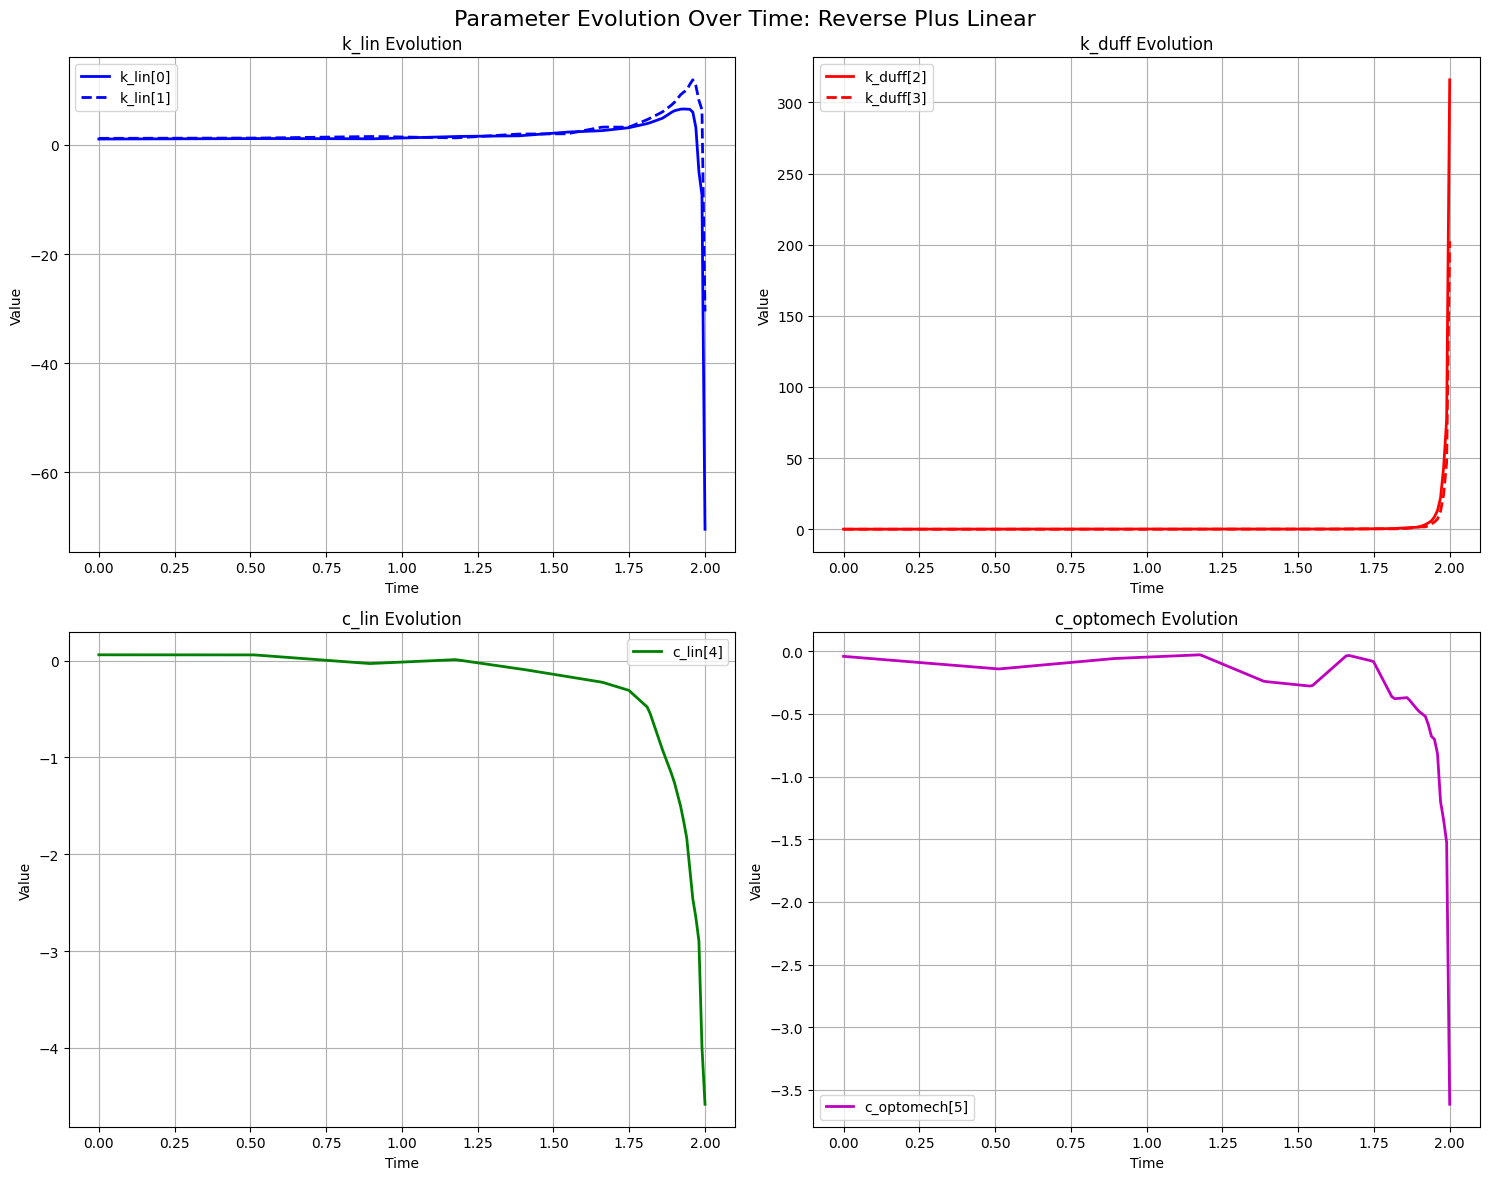

In [17]:
# Create time points for evaluation
time_eval = jnp.linspace(0, t_forward, 200)

# Get parameters at each time point
params_over_time = jnp.vstack([params_interpolator_reverse_plus_linear(t) for t in time_eval])

# Create figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Parameter Evolution Over Time: Reverse Plus Linear', fontsize=16)

# Plot settings
param_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech']
axes = [ax1, ax2, ax3, ax4]
colors = ['b', 'r', 'g', 'm']
param_indices = [(0,1), (2,3), (4,), (5,)]

# Plot for each parameter type
for ax, param_name, color, indices in zip(axes, param_names, colors, param_indices):
    for idx, style in zip(indices, ['-', '--']):
        ax.plot(time_eval, params_over_time[:, idx], color + style, linewidth=2,
                label=f'{param_name}[{idx}]')
    
    ax.set_title(f'{param_name} Evolution')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [18]:
# Setup SDE functions
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator_reverse_plus_linear, N_osc, time_dependent_parms=True, T=diffusion_rate)

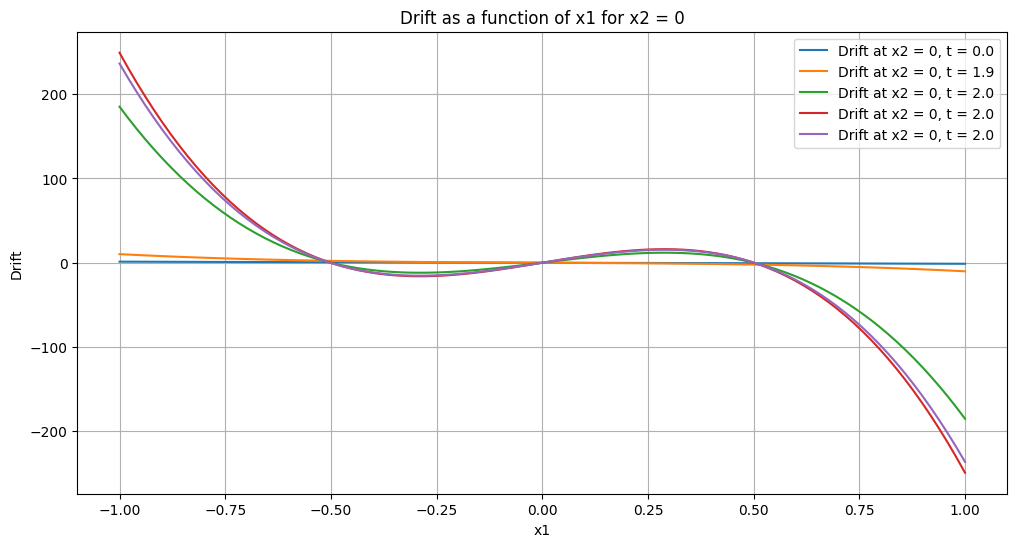

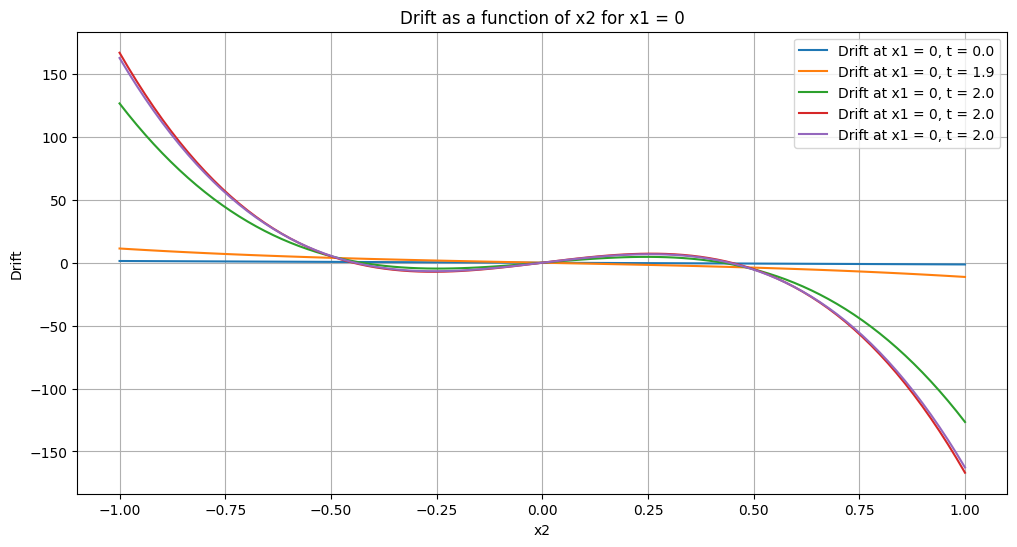

In [19]:
# Assuming drift_fn is already defined and takes (time, state, args) as input
# Define the range for x1 and x2
x_range = jnp.linspace(-1, 1, 100)  # Example range from -5 to 5

# Define filename for saving/loading parameters
n_time_steps = 5
# forward_time_pts = jnp.linspace(0., t_forward, n_time_steps)
time_steps = t_forward - jnp.exp(jnp.linspace(jnp.log(t_forward), jnp.log(1e-6), n_time_steps))


# Plot drift as a function of x1 for x2 = 0
plt.figure(figsize=(12, 6))
for t in time_steps:
    drift_x1 = [drift_fn(t, jnp.array([x1, 0]), args=())[0] for x1 in x_range]
    plt.plot(x_range, drift_x1, label=f'Drift at x2 = 0, t = {t:.1f}')

plt.xlabel('x1')
plt.ylabel('Drift')
plt.title('Drift as a function of x1 for x2 = 0')
plt.legend()
plt.grid(True)
plt.show()

# Plot drift as a function of x2 for x1 = 0
plt.figure(figsize=(12, 6))
for t in time_steps:
    drift_x2 = [drift_fn(t, jnp.array([0, x2]), args=())[1] for x2 in x_range]
    plt.plot(x_range, drift_x2, label=f'Drift at x1 = 0, t = {t:.1f}')

plt.xlabel('x2')
plt.ylabel('Drift')
plt.title('Drift as a function of x2 for x1 = 0')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
t0 = 0.0
t1 = t_forward
ts = jnp.linspace(t0, t1, 100)
dt0 = ts[1] - ts[0]

# Generate multiple initial states
# n_trajectories = 2000
# key, subkey = jr.split(key)
# initial_states = sample_forward_process(t_forward, n_trajectories, D=1, samples0=samples_0, key=subkey, diffusion_rate=diffusion_rate)
# Sample initial conditions from N(0, I)
n_trajectories = 1000  # or any other number of trajectories you need
n_dimensions = 2  # assuming 2D, adjust as necessary
key, subkey = jr.split(key)
initial_states = jr.normal(subkey, (n_trajectories, n_dimensions))

# Generate a key for each initial condition
key, subkey = jr.split(key)
keys_brownian = jr.split(subkey, n_trajectories)

# Vectorize solve_SDE across both initial states and keys
vectorized_solve_SDE = vmap(
    lambda init_state, key_b: solve_SDE(
        drift_fn, 
        diffusion_fn, 
        init_state,
        key_b, 
        t0, 
        t1, 
        ts.shape[0], 
        dt0
    ),
    in_axes=(0, 0)
)


# Run SDE for all initial states at once
solutions = vectorized_solve_SDE(initial_states, keys_brownian)
all_trajectories = solutions.ys  # Shape: (n_trajectories, n_timesteps, 2)
final_states = all_trajectories[:, -1, :]  # Shape: (n_trajectories, 2)


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

In [21]:
solve_time = 0.0
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator(solve_time), N_osc,time_dependent_parms=False)
t0 = 0.0
t1 = 100 
ts = jnp.linspace(t0, t1, 1000)
dt0 = ts[1] - ts[0]
initial_state = jnp.array([-.5,0.])
key_equilibrium = jr.PRNGKey(111111)
solution_direct = solve_SDE(drift_fn, diffusion_fn, initial_state,key_equilibrium, t0, t1, ts.shape[0], dt0)
sde_samples_direct = solution_direct.ys


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

In [22]:
# param_list = [params_interpolator(solve_time)]
# titles = ["Solution from direct integration "]
# plot_energy_and_distributions(
#     energy_fn=energy_fn,
#     param_list=param_list,
#     samples=sde_samples_direct,
#     sample_stride=1,
#     x1_range=(-1, 1),    
#     x2_range=(-1, 1),    
#     n_points=30,    
#     titles=titles,       
#     figsize=None,    
#     fontsize=12,         
#     suptitle="Energy landscape with SDE samples"  
# )

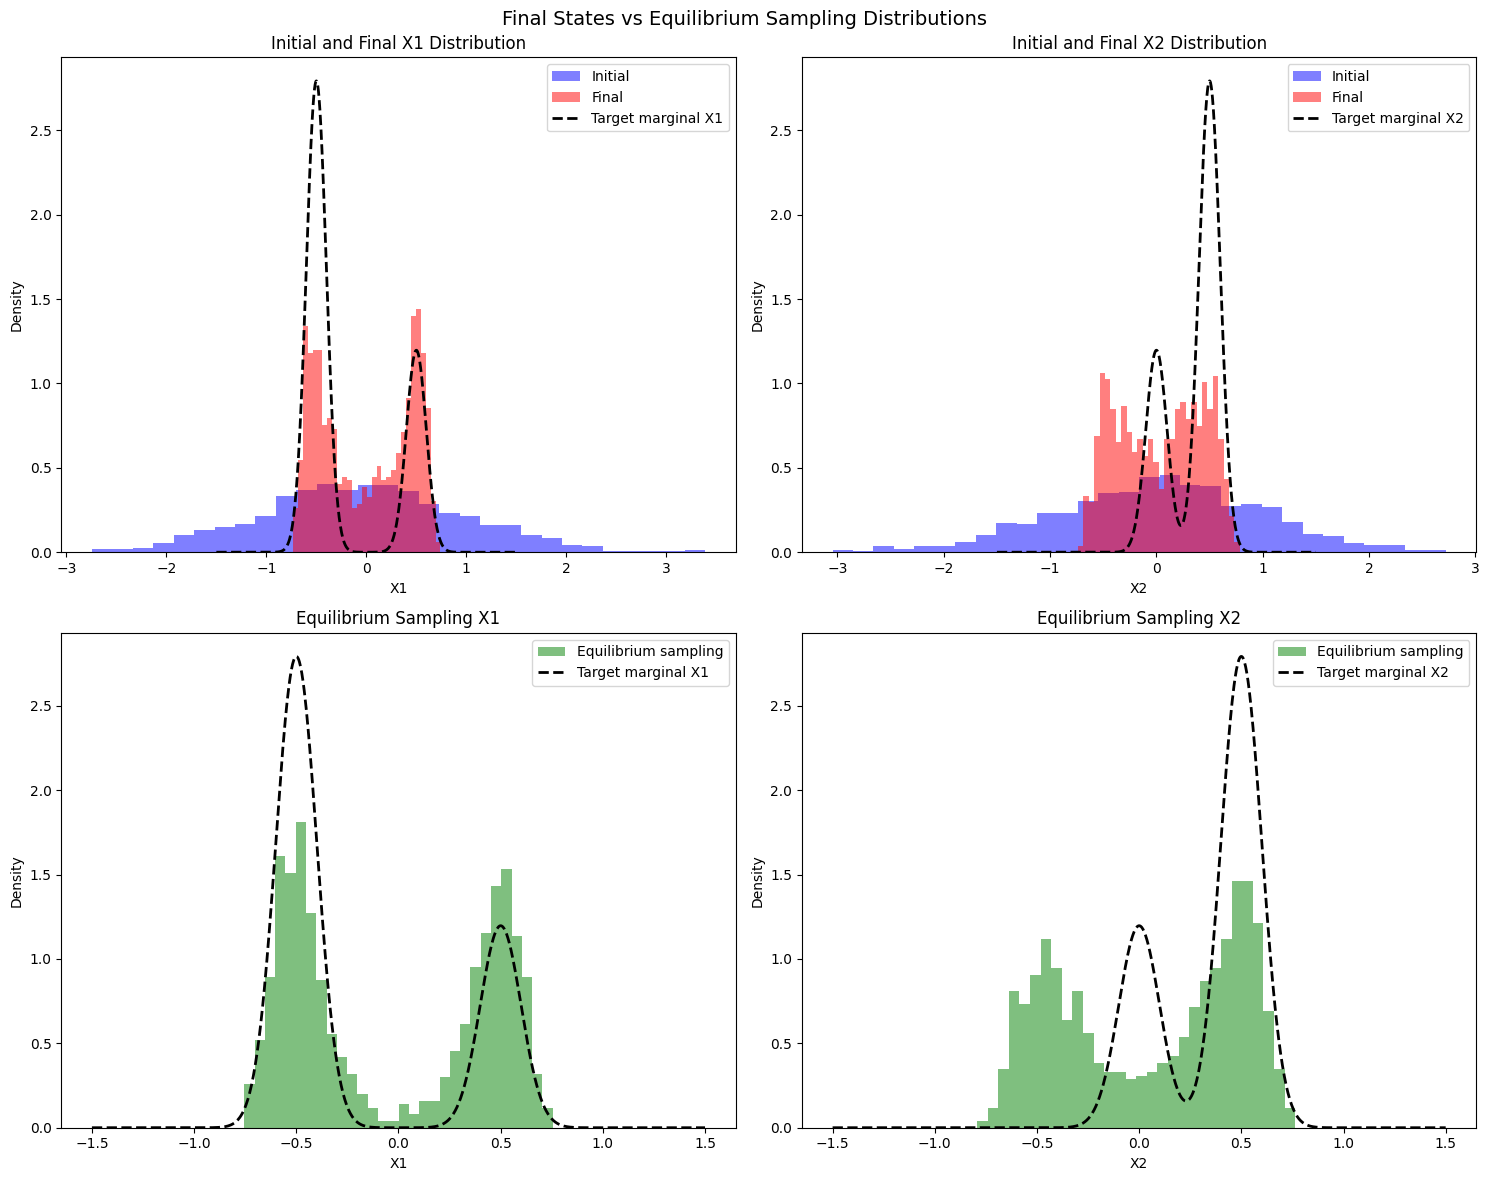

In [23]:
# Create 2x2 subplot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Final States vs Equilibrium Sampling Distributions', fontsize=14)

# Top row: Initial and Final states
ax1.hist(initial_states[:, 0], bins=30, alpha=0.5, density=True, label='Initial', color='blue')
ax1.hist(final_states[:, 0], bins=30, alpha=0.5, density=True, label='Final', color='red')
ax2.hist(initial_states[:, 1], bins=30, alpha=0.5, density=True, label='Initial', color='blue')
ax2.hist(final_states[:, 1], bins=30, alpha=0.5, density=True, label='Final', color='red')

# Bottom row: Equilibrium sampling in green
ax3.hist(sde_samples_direct[:, 0], bins=30, alpha=0.5, density=True, label='Equilibrium sampling', color='green')
ax4.hist(sde_samples_direct[:, 1], bins=30, alpha=0.5, density=True, label='Equilibrium sampling', color='green')

# Add exact marginal Gaussians to all plots
x = jnp.linspace(-1.5, 1.5, 1000)

# Plot marginals for each subplot separately with correct dimension
for ax, dim in [(ax1, 0), (ax2, 1), (ax3, 0), (ax4, 1)]:
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax.plot(x, marginal, '--k', linewidth=2, label=f'Target marginal {["X1", "X2"][dim]}')

# Set titles and labels
ax1.set_title('Initial and Final X1 Distribution')
ax1.set_xlabel('X1')
ax1.set_ylabel('Density')
ax1.legend()

ax2.set_title('Initial and Final X2 Distribution')
ax2.set_xlabel('X2')
ax2.set_ylabel('Density')
ax2.legend()

ax3.set_title('Equilibrium Sampling X1')
ax3.set_xlabel('X1')
ax3.set_ylabel('Density')
ax3.legend()

ax4.set_title('Equilibrium Sampling X2')
ax4.set_xlabel('X2')
ax4.set_ylabel('Density')
ax4.legend()

plt.tight_layout()
plt.show()